In [1]:
from pipelines.POT_Function import POT_Hourly, POT_Daily
from pipelines.Design_Based_Isolines import get_samples_on_isolines_and_plot
from pipelines.Response_Based_Coreset_Kmeans import coreset_kmeans, plot_kmeans_inertia, visualize_representative_space_vs_entire_space, find_optimal_lower_upper
import pandas as pd
from pipelines.Find_TimeSeries_of_POTs import timeseries_of_pot_center_variable_hourly, timeseries_of_pot_center_variable_daily
from pathlib import Path
import glob
from pipelines.Scale_and_Align_Synthetic_Samples_to_TimeSeries import OriginalSeries, VariableSpec, scale_and_align_events
from pipelines.RF_Spatial import rainfall_spatial_distributed_gauges_wise
import numpy as np
from datetime import timedelta


In [10]:
input_files = Path('C:/Users/sadaf/Desktop/Generating_Boundary_Conditions/Multivariate_Codes/Github/input')
output_directory = Path('C:/Users/sadaf/Desktop/Generating_Boundary_Conditions/Multivariate_Codes/Github/outputs')

# 1. POTs and associated max of three variables

In [11]:
n_events = 5
POT_Daily('dateTime','time','time','discharge_m3s','Storm_Surge_predicted_RF','acc_24hr',
          
          input_files / ('usgs_discharge.csv'),
          input_files / ('NOAA_Tide_Gauge_MSL_All_Predicted.csv'),
          input_files / ('GHCN_Rainfall_1950_2050_hourly_accumulated.csv'),

          'POT_RD','Max_NTR','Max_RF', n_events, 

          output_directory / ('Thresholds_RD.csv'),
          output_directory / ('POT_RD_Functions.csv'),
          
          stationary=False)

(          time     POT_RD   Max_NTR      Max_RF
 0   1952-12-05  11.156838  0.237631    8.400000
 1   1952-12-10   6.796043  0.298682   70.600000
 2   1952-12-20   9.287926  0.279863   11.900000
 3   1952-12-26  17.216643  0.252681   29.700000
 4   1952-12-31  53.518840  0.399136   50.000000
 ..         ...        ...       ...         ...
 360 2024-01-09  64.562410  0.818683   45.700000
 361 2024-01-26  41.059428  0.314736   22.100000
 362 2024-04-11  75.889149  0.471419   64.300000
 363 2024-05-14  49.837650  0.168069  174.000000
 364 2024-09-12  42.192101  0.086757   26.609177
 
 [365 rows x 4 columns],
     Year   Threshold
 0   1952    6.796043
 1   1953   45.306955
 2   1954    9.797629
 3   1955   35.396058
 4   1956   28.883184
 ..   ...         ...
 69  2021  102.790153
 70  2022   33.413879
 71  2023   21.520803
 72  2024   41.059428
 73  2025   18.037831
 
 [74 rows x 2 columns])

In [ ]:
n_events = 5
POT_Hourly('time','time','dateTime','acc_24hr','Storm_Surge_predicted_RF','discharge_m3s',
           
           input_files / ('GHCN_Rainfall_1950_2050_hourly_accumulated.csv'),
           input_files / ('NOAA_Tide_Gauge_MSL_All_Predicted.csv'),
           input_files / ('usgs_discharge.csv'),

           'POT_RF','Max_NTR','Max_RD', n_events,

           output_directory / ('Thresholds_RF.csv'),
           output_directory / ('POT_RF_Functions.csv'),
           
          stationary=False
          )

c:\Users\sadaf\Desktop\Generating_Boundary_Conditions\Multivariate_Codes\Github\pipelines\POT_Function.py:276: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_pot.index = pd.to_datetime(df_pot.index).round('H')


(                   time      POT_RF   Max_NTR     Max_RD
 14  1952-12-09 23:00:00   70.600000  0.298682   6.796043
 15  1953-02-14 23:00:00   63.200000  0.488232  32.847542
 16  1953-04-06 23:00:00   57.200000  0.248979   5.493468
 17  1953-06-27 23:00:00   68.600000  0.256226  45.306955
 18  1953-08-19 23:00:00   77.000000 -0.003151   5.550102
 ..                  ...         ...       ...        ...
 370 2024-04-10 23:00:00   64.300000  0.471419  75.889149
 371 2024-05-13 23:00:00  174.000000  0.168069  49.837650
 372 2024-07-15 23:00:00   67.800000 -0.006381   1.112852
 373 2024-11-19 23:00:00   52.300000  0.438454   1.537605
 374 2024-12-28 07:00:00   95.908884  0.393922  32.281205
 
 [361 rows x 4 columns],
     Year  Threshold
 0   1950  67.300000
 1   1951  60.200000
 2   1952  67.407158
 3   1953  57.200000
 4   1954  52.800000
 ..   ...        ...
 71  2021  81.000000
 72  2022  50.300000
 73  2023  57.200000
 74  2024  52.300000
 75  2025  33.300000
 
 [76 rows x 2 columns])

In [ ]:
n_events = 5
POT_Hourly('time','time','dateTime','Storm_Surge_predicted_RF','acc_24hr','discharge_m3s',
           
           input_files / ('NOAA_Tide_Gauge_MSL_All_Predicted.csv'),
           input_files / ('GHCN_Rainfall_1950_2050_hourly_accumulated.csv'),
           input_files / ('usgs_discharge.csv'),

           'POT_NTR','Max_RF','Max_RD',  n_events,
           
           output_directory / ('Thresholds_NTR.csv'),
           output_directory / ('POT_NTR_Functions.csv'),
           
          stationary=False
          )

Skipping 2025: not enough independent events.


c:\Users\sadaf\Desktop\Generating_Boundary_Conditions\Multivariate_Codes\Github\pipelines\POT_Function.py:276: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_pot.index = pd.to_datetime(df_pot.index).round('H')


(                   time   POT_NTR     Max_RF     Max_RD
 15  1953-01-09 06:00:00  0.447390  17.500000   5.125349
 16  1953-01-23 15:00:00  0.454100  28.400000  17.981198
 17  1953-02-15 01:00:00  0.488232  63.200000  32.847542
 18  1953-06-06 08:00:00  0.437640   1.800000   0.195386
 19  1953-12-04 09:00:00  0.424015  65.837540  46.439628
 ..                  ...       ...        ...        ...
 370 2024-01-06 06:00:00  0.484790  36.100000   6.937627
 371 2024-01-09 13:00:00  0.818683  45.700000  64.562410
 372 2024-01-12 16:00:00  0.477426  32.988832  33.980216
 373 2024-02-12 08:00:00  0.473086  15.000000  21.577437
 374 2024-04-10 23:00:00  0.471419  64.300000  75.889149
 
 [360 rows x 4 columns],
     Year  Threshold
 0   1950   0.357520
 1   1951   0.334546
 2   1952   0.427094
 3   1953   0.424015
 4   1954   0.341486
 ..   ...        ...
 70  2020   0.457288
 71  2021   0.386249
 72  2022   0.405231
 73  2023   0.387239
 74  2024   0.471419
 
 [75 rows x 2 columns])

## In this step, we need to use R for marginal distributions and copula analysis. 

## Please go to the R workflow provided for you and run the workflow. Then come back to this notebook.

# 3. Design-based Isolines

RP=1: 100 samples
RP=5: 100 samples
RP=10: 100 samples
RP=20: 100 samples
RP=50: 100 samples
RP=100: 100 samples


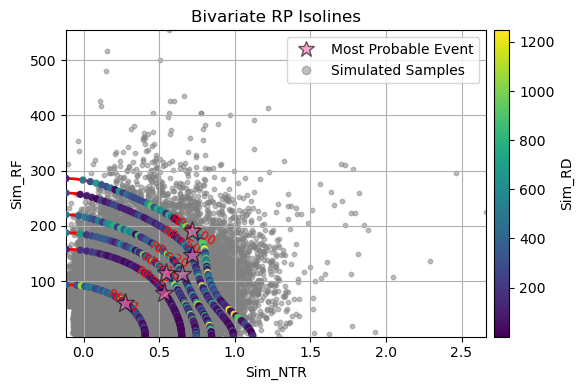

In [ ]:
rp_vals = [1, 5, 10, 20, 50, 100]

df_isolines = get_samples_on_isolines_and_plot(
    variable_1_simulated_col="Sim_NTR",
    variable_2_simulated_col="Sim_RF",
    variable_3_simulated_col="Sim_RD",

    variable_1_input_path=output_directory / ('Simulated_Backtransformed_POT_NTR.csv'),
    variable_2_input_path=output_directory / ('Simulated_Backtransformed_POT_RF.csv'),
    variable_3_input_path=output_directory / ('Simulated_Backtransformed_POT_RD.csv'),

    density_col="Density",

    rp_col="ReturnPeriod_Bivariate",
    
    number_of_events_per_year=5,
    samples_per_isoline=100,

    output_plot_path=output_directory / ('Plot_Isolines.png'),
    output_data_path=output_directory,

    rp_vals=rp_vals
)

# 4. Response-based Weighted Coreset Kmeans

In [ ]:
base_path = output_directory 

# --------------------------------
# RF
# --------------------------------
df = pd.read_csv(rf'{base_path}/Simulated_Backtransformed_POT_RF.csv')

body_df, tail_df, diagnostics = find_optimal_lower_upper(
    df,
    u_cols=("U_RF","U_RD","U_NTR"),
    raw_cols=("Sim_RF","Sim_RD","Sim_NTR"),
    q_upper=0.99,
    k_grid_body=list(range(200, 2601, 200)),
    k_grid_tail=list(range(50, 801, 50)),
    bins=6,
    eps_cover=0.18,
    eps_hist=0.18,
    patience=3,
    stop_mode_body="either",  # <-- makes body smaller
    stop_mode_tail="both"     # <-- keeps tail conservative
)
print(diagnostics["k_body_opt"], diagnostics["k_tail_opt"])

df_all_rf = pd.concat([body_df,tail_df])
df_all_rf.to_csv(rf'{base_path}/coreset_RF_V2.csv')
# --------------------------------
# NTR
# --------------------------------
df = pd.read_csv(rf'{base_path}/Simulated_Backtransformed_POT_NTR.csv')

body_df, tail_df, diagnostics = find_optimal_lower_upper(
    df,
    u_cols=("U_NTR","U_RF","U_RD",),
    raw_cols=("Sim_NTR","Sim_RF","Sim_RD"),
    q_upper=0.99,
    k_grid_body=list(range(200, 2601, 200)),
    k_grid_tail=list(range(50, 801, 50)),
    bins=6,
    eps_cover=0.1,
    eps_hist=0.1,
    patience=2,
    stop_mode_body="either",  # <-- makes body smaller
    stop_mode_tail="both"     # <-- keeps tail conservative
)
print(diagnostics["k_body_opt"], diagnostics["k_tail_opt"])

df_all_ntr = pd.concat([body_df,tail_df])
df_all_ntr.to_csv(rf'{base_path}/coreset_NTR_V2.csv')
# --------------------------------
# RD
# --------------------------------
df = pd.read_csv(rf'{base_path}/Simulated_Backtransformed_POT_RD.csv')

body_df, tail_df, diagnostics = find_optimal_lower_upper(
    df,
    u_cols=("U_RD","U_RF","U_NTR"),
    raw_cols=("Sim_RD","Sim_RF","Sim_NTR"),
    q_upper=0.99,
    k_grid_body=list(range(200, 2601, 200)),
    k_grid_tail=list(range(50, 801, 50)),
    bins=6,
    eps_cover=0.12,
    eps_hist=0.12,
    patience=2,
    stop_mode_body="either",  # <-- makes body smaller
    stop_mode_tail="both"     # <-- keeps tail conservative
)
print(diagnostics["k_body_opt"], diagnostics["k_tail_opt"])

df_all_rd = pd.concat([body_df,tail_df])
df_all_rd.to_csv(rf'{base_path}/coreset_RD_V2.csv')


representative_events_all = pd.concat(
    [
        df_all_rf,
        df_all_ntr,
        df_all_rd
    ],
    ignore_index=True
)


# --------------------------------
# Save combined dataframe
# --------------------------------
output_all = (
    output_directory / "representative_events_entire_space_tail_body.csv"
)

representative_events_all.to_csv(
    output_all,
    index=False
)

1000 700
1200 650
1000 700


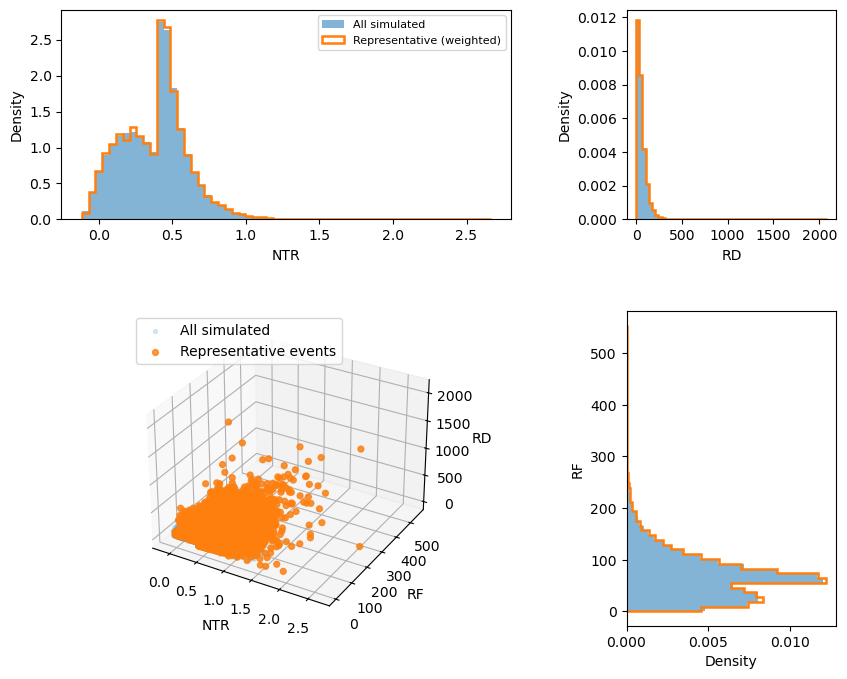

In [ ]:
entire_space_ntr = pd.read_csv(output_directory / ('Simulated_Backtransformed_POT_NTR.csv'))
entire_space_rf = pd.read_csv(output_directory / ('Simulated_Backtransformed_POT_RF.csv'))
entire_space_rd = pd.read_csv(output_directory / ('Simulated_Backtransformed_POT_RD.csv'))

events_all = pd.concat(
    [
        entire_space_ntr,
        entire_space_rf,
        entire_space_rd
    ],
    ignore_index=True
)


# --------------------------------
# Save combined dataframe
# --------------------------------
output_all = (
    output_directory / r"events_entire_space.csv"
)

events_all.to_csv(
    output_all,
    index=False
)

fig = visualize_representative_space_vs_entire_space(
    representative_space_path=output_directory / ("representative_events_entire_space.csv"),

    entire_space_path=output_directory /  ("events_entire_space.csv"),

    variable_1_simulated_col_name="Sim_NTR",
    variable_2_simulated_col_name="Sim_RF",
    variable_3_simulated_col_name="Sim_RD",

    variable_1_axis_name="NTR",
    variable_2_axis_name="RF",
    variable_3_axis_name="RD",

    weight_col="Weight",
    bins=60
)

# 6. Find timeseries associated with POTs and associated variables

In [ ]:
# --------------------------------
# 1. NTR-centered POT events
# NTR = hourly center
# RF  = hourly associated variable
# RD  = daily associated variable
# --------------------------------
ntr_windows = timeseries_of_pot_center_variable_hourly(
    pot_center_variable_path=output_directory / ("POT_NTR_Functions.csv"),
    pot_time_col="time",

    original_dataset_center_variable_path=input_files / ("NOAA_Tide_Gauge_MSL_All_Predicted.csv"),
    original_dataset_center_variable_time_col="time",
    original_dataset_center_variable_col_name="Storm_Surge_predicted_RF",

    original_dataset_associated_variable_1_path=input_files / ("GHCN_Rainfall_1950_2050_hourly_accumulated.csv"),
    original_dataset_associated_variable_1_time_col="time",
    original_dataset_associated_variable_1_col_name="acc_24hr",
    lag_hour_col_variable_1="Lag_RF_minus_NTR_hr",

    original_dataset_associated_variable_2_path=input_files / ("usgs_discharge.csv"),
    original_dataset_associated_variable_2_time_col="dateTime",
    original_dataset_associated_variable_2_col_name="discharge_m3s",
    lag_hour_col_variable_2="Lag_RD_minus_NTR_hr",

    output_path=output_directory / ("POT_NTR_timeseries.csv"),

    window_days=10,
)

# --------------------------------
# 2. RF-centered POT events
# RF = hourly center
# NTR  = hourly associated variable
# RD  = daily associated variable
# --------------------------------
rf_windows = timeseries_of_pot_center_variable_hourly(
    pot_center_variable_path=output_directory / ("POT_RF_Functions.csv"),
    pot_time_col="time",

    original_dataset_center_variable_path=input_files / ("GHCN_Rainfall_1950_2050_hourly_accumulated.csv"),
    original_dataset_center_variable_time_col="time",
    original_dataset_center_variable_col_name="acc_24hr",

    original_dataset_associated_variable_1_path=input_files / ("NOAA_Tide_Gauge_MSL_All_Predicted.csv"),
    original_dataset_associated_variable_1_time_col="time",
    original_dataset_associated_variable_1_col_name="Storm_Surge_predicted_RF",
    lag_hour_col_variable_1="Lag_NTR_minus_RF_hr",

    original_dataset_associated_variable_2_path=input_files / ("usgs_discharge.csv"),
    original_dataset_associated_variable_2_time_col="dateTime",
    original_dataset_associated_variable_2_col_name="discharge_m3s",
    lag_hour_col_variable_2="Lag_RD_minus_RF_hr",

    output_path=output_directory / ("POT_RF_timeseries.csv"),

    window_days=10,
)

# --------------------------------
# 3. RD-centered POT events
# RD = daily center
# RF and NTR = hourly associated variables
# --------------------------------
rd_df = timeseries_of_pot_center_variable_daily(
    pot_center_variable_path=output_directory / ("POT_RD_Functions.csv"),
    pot_time_col="time",

    original_dataset_center_variable_path=input_files / ("usgs_discharge.csv"),
    original_dataset_center_variable_time_col="dateTime",
    original_dataset_center_variable_col_name="discharge_m3s",

    original_dataset_associated_variable_1_path=input_files / ("GHCN_Rainfall_1950_2050_hourly_accumulated.csv"),
    original_dataset_associated_variable_1_time_col="time",
    original_dataset_associated_variable_1_col_name="acc_24hr",
    lag_hour_col_variable_1="Lag_RF_minus_RD_hr",

    original_dataset_associated_variable_2_path=input_files / ("NOAA_Tide_Gauge_MSL_All_Predicted.csv"),
    original_dataset_associated_variable_2_time_col="time",
    original_dataset_associated_variable_2_col_name="Storm_Surge_predicted_RF",
    lag_hour_col_variable_2="Lag_NTR_minus_RD_hr",

    output_path=output_directory / ("POT_RD_timeSeries.csv"),

    window_days=10,
)


# 7. Scale and Align Synthetic Samples to TimeSeries based on Historical TimeSeries

In [ ]:
# --------------------------------
# 1. NTR-centered POT events
# NTR = hourly center
# RF  = hourly associated variable, 1 station
# RD  = daily associated variable, 2 stations
# --------------------------------
base_path = Path(output_directory)

ntr = VariableSpec(
    name="NTR",
    target_col="Sim_NTR",
    pot_peak_col="POT_NTR",
    pot_ts_value_col="Storm_Surge_predicted_RF",
    sampling_power=2,
    lag_col=None,
    output_col="NTR (m)",
)

rf = VariableSpec(
    name="RF",
    target_col="Sim_RF",
    pot_peak_col="Max_RF",
    pot_ts_value_col="acc_24hr",
    sampling_power=1.8,
    lag_col="Lag_RF_minus_NTR_hr",
    max_abs_lag_hours=120,
    cutoff="1978-12-31",
    original_series=[
        OriginalSeries(
            path=input_files / ("GHCN_Rainfall_1950_2050_hourly_accumulated.csv"),
            time_col="time",
            value_col="Rainf_hourly",
            output_col="RF (mm/hr)",
            rainfall_kind="hourly",
        )
    ],
)

rd = VariableSpec(
    name="RD",
    target_col="Sim_RD",
    pot_peak_col="Max_RD",
    pot_ts_value_col="discharge_m3s",
    sampling_power=2.0,
    lag_col="Lag_RD_minus_NTR_hr",
    max_abs_lag_hours=120,
    cutoff="1993-11-11",
    original_series=[
        OriginalSeries(
            path=input_files / ("usgs_02481000_discharge_hourly.csv"),
            time_col="datetime",
            value_col="discharge_m3s",
            output_col="RD_Biloxi (m3/s)",
        ),

        OriginalSeries(
            path=input_files / ("usgs_02479310_discharge_hourly.csv"),
            time_col="datetime",
            value_col="discharge_m3s",
            output_col="RD_Pascagoula (m3/s)",
        ),
    ],
)

# --------------------------------
# Reponse-Based
# --------------------------------
manifest, output_files = scale_and_align_events(
    center_variable="NTR",

    # Historical POT
    pot_path=output_directory / ("POT_NTR_Functions.csv"),
    pot_time_col="time",

    # Historical ±event windows
    pot_timeseries_path=base_path / ("POT_NTR_timeseries.csv"),
    pot_timeseries_time_col="time",
    pot_timeseries_event_time_col="event_time",

    # Variable definitions
    variables=[
        ntr,
        rf,
        rd,
    ],

    # Response-based representative events
    mode="response",
    response_samples_path=base_path / "coreset_NTR_V2.csv",
    output_directory=base_path / "Scaled_Events" / "Response_based" /"NTR",
    weight_col="Weights",
    random_state=42,
    filename_prefix="NTR_Event",
    drop_incomplete_rows=True,
)

# --------------------------------
# Design-Based
# --------------------------------

manifest, output_files = scale_and_align_events(
    center_variable="NTR",

    # Historical POT
    pot_path=(base_path / "POT_NTR_Functions.csv"),
    pot_time_col="time",

    # Historical ± event windows
    pot_timeseries_path=base_path / "POT_NTR_timeseries.csv",
    pot_timeseries_time_col="time",
    pot_timeseries_event_time_col="event_time",

    # Variable definitions
    variables=[
        ntr,
        rf,
        rd,
    ],

    # --------------------------------
    # Design-based samples
    # --------------------------------
    mode="design",
    years=[1,5,10,20,50,100],
    design_samples_directory=base_path,
    design_filename_template=(
        "Synthetic_{year}yr_Bivariate_from_Trivariate_5.csv"
    ),
    return_period_col="RP",

    # --------------------------------
    # Output
    # --------------------------------
    output_directory=(base_path / "Scaled_Events" / "Design_based" / "NTR"),
    random_state=42,
    filename_prefix="NTR_Event",
    drop_incomplete_rows=True,
)

In [ ]:
# --------------------------------
# 1. RF-centered POT events
# RF = hourly center
# NTR  = hourly associated variable, 1 station
# RD  = daily associated variable, 2 stations
# --------------------------------
base_path = Path(output_directory)

rf = VariableSpec(
    name="RF",
    target_col="Sim_RF",
    pot_peak_col="POT_RF",
    pot_ts_value_col="acc_24hr",
    sampling_power=1.8,
    lag_col=None,
    cutoff="1978-12-31",
    original_series=[
        OriginalSeries(
            path=input_files / ("GHCN_Rainfall_1950_2050_hourly_accumulated.csv"),
            time_col="time",
            value_col="Rainf_hourly",
            output_col="RF (mm/hr)",
            rainfall_kind="hourly",
        )
    ],
)

ntr = VariableSpec(
    name="NTR",
    target_col="Sim_NTR",
    pot_peak_col="Max_NTR",
    pot_ts_value_col="Storm_Surge_predicted_RF",
    sampling_power=2,
    lag_col="Lag_NTR_minus_RF_hr",
    max_abs_lag_hours=120,
    output_col="NTR (m)",
)

rd = VariableSpec(
    name="RD",
    target_col="Sim_RD",
    pot_peak_col="Max_RD",
    pot_ts_value_col="discharge_m3s",
    sampling_power=2.0,
    lag_col="Lag_RD_minus_RF_hr",
    max_abs_lag_hours=120,
    cutoff="1993-11-11",
    original_series=[
        OriginalSeries(
            path=input_files / ("usgs_02481000_discharge_hourly.csv"),
            time_col="datetime",
            value_col="discharge_m3s",
            output_col="RD_Biloxi (m3/s)",
        ),

        OriginalSeries(
            path=input_files / ("usgs_02479310_discharge_hourly.csv"),
            time_col="datetime",
            value_col="discharge_m3s",
            output_col="RD_Pascagoula (m3/s)",
        ),
    ],
)

# --------------------------------
# Reponse-Based
# --------------------------------
manifest, output_files = scale_and_align_events(
    center_variable="RF",

    # Historical POT
    pot_path=(base_path / "POT_RF_Functions.csv"),
    pot_time_col="time",

    # Historical ±event windows
    pot_timeseries_path=base_path / "POT_RF_timeseries.csv",
    pot_timeseries_time_col="time",
    pot_timeseries_event_time_col="event_time",

    # Variable definitions
    variables=[
        rf,
        ntr,
        rd,
    ],

    # Response-based representative events
    mode="response",
    response_samples_path=base_path / "coreset_RF_V2.csv",
    output_directory=base_path / "Scaled_Events" / "Response_based" /"RF",
    weight_col="Weights",
    random_state=42,
    filename_prefix="RF_Event",
    drop_incomplete_rows=True,
)

# --------------------------------
# Design-Based
# --------------------------------

manifest, output_files = scale_and_align_events(
    center_variable="RF",

    # Historical POT
    pot_path=(base_path / "POT_RF_Functions.csv"),
    pot_time_col="time",

    # Historical ± event windows
    pot_timeseries_path=base_path / "POT_RF_timeseries.csv",
    pot_timeseries_time_col="time",
    pot_timeseries_event_time_col="event_time",

    # Variable definitions
    variables=[
        rf,
        ntr,
        rd,
    ],

    # --------------------------------
    # Design-based samples
    # --------------------------------
    mode="design",
    years=[1,5,10,20,50,100],
    design_samples_directory=base_path,
    design_filename_template=(
        "Synthetic_{year}yr_Bivariate_from_Trivariate_5.csv"
    ),
    return_period_col="RP",

    # --------------------------------
    # Output
    # --------------------------------
    output_directory=(base_path / "Scaled_Events" / "Design_based" / "RF"),
    random_state=42,
    filename_prefix="RF_Event",
    drop_incomplete_rows=True,
)

In [ ]:
# --------------------------------
# 3. RD-centered POT events
# RD  = center variable
# NTR = hourly associated variable, 1 station
# RF  = hourly associated variable, 1 station
# --------------------------------

base_path = output_directory

# ============================================================
# Variable definitions
# ============================================================

rd = VariableSpec(
    name="RD",
    target_col="Sim_RD",
    pot_peak_col="POT_RD",
    pot_ts_value_col="discharge_m3s",
    sampling_power=2.0,
    lag_col=None,
    cutoff="1993-11-11",

    original_series=[
        OriginalSeries(
            path=(
                input_files / ("usgs_02481000_discharge_hourly.csv")
            ),
            time_col="datetime",
            value_col="discharge_m3s",
            output_col="RD_Biloxi (m3/s)",
        ),

        OriginalSeries(
            path=(
                input_files / ("usgs_02479310_discharge_hourly.csv")
            ),
            time_col="datetime",
            value_col="discharge_m3s",
            output_col="RD_Pascagoula (m3/s)",
        ),
    ],
)


ntr = VariableSpec(
    name="NTR",
    target_col="Sim_NTR",
    pot_peak_col="Max_NTR",
    pot_ts_value_col="Storm_Surge_predicted_RF",
    sampling_power=2.0,
    lag_col="Lag_NTR_minus_RD_hr",
    max_abs_lag_hours=120,
    output_col="NTR (m)",
)


rf = VariableSpec(
    name="RF",
    target_col="Sim_RF",
    pot_peak_col="Max_RF",
    pot_ts_value_col="acc_24hr",
    sampling_power=1.8,
    lag_col="Lag_RF_minus_RD_hr",
    max_abs_lag_hours=120,
    cutoff="1978-12-31",

    original_series=[
        OriginalSeries(
            path=(
                input_files / ("GHCN_Rainfall_1950_2050_hourly_accumulated.csv")
            ),
            time_col="time",
            value_col="Rainf_hourly",
            output_col="RF (mm/hr)",
            rainfall_kind="hourly",
        )
    ],
)


# ============================================================
# Response-Based
# ============================================================

manifest_response_rd, output_files_response_rd = scale_and_align_events(
    center_variable="RD",

    # Historical POT
    pot_path=base_path / "POT_RD_Functions.csv",
    pot_time_col="time",

    # Historical ± event windows
    pot_timeseries_path=base_path / "POT_RD_timeseries.csv",
    pot_timeseries_time_col="time",
    pot_timeseries_event_time_col="event_time",

    # Variable definitions
    variables=[
        rd,
        ntr,
        rf,
    ],

    # Response-based representative events
    mode="response",
    response_samples_path=base_path / "coreset_RD_V2.csv",
    output_directory=(
        base_path / "Scaled_Events" / "Response_based" / "RD"
    ),
    weight_col="Weights",
    random_state=42,
    filename_prefix="RD_Event",
    drop_incomplete_rows=True,
)


# ============================================================
# Design-Based
# ============================================================

manifest_design_rd, output_files_design_rd = scale_and_align_events(
    center_variable="RD",

    # Historical POT
    pot_path=base_path / "POT_RD_Functions.csv",
    pot_time_col="time",

    # Historical ± event windows
    pot_timeseries_path=base_path / "POT_RD_timeseries.csv",
    pot_timeseries_time_col="time",
    pot_timeseries_event_time_col="event_time",

    # Variable definitions
    variables=[
        rd,
        ntr,
        rf,
    ],

    # Design-based samples
    mode="design",
    years=[1,5,10,20,50,100],
    design_samples_directory=base_path,
    design_filename_template=(
        "Synthetic_{year}yr_Bivariate_from_Trivariate_5.csv"
    ),

    return_period_col="RP",
    output_directory=(
        base_path / "Scaled_Events" / "Design_based" / "RD"
    ),
    random_state=42,
    filename_prefix="RD_Event",
    drop_incomplete_rows=True,
)

# 8. Convert time series of rainfall to spatially distributed rainfall

In [ ]:
spatial_rainfall = rainfall_spatial_distributed_gauges_wise(dir_path= output_directory / 'Scaled_Events'/'Design_based'/'RF',
                                             nldas_path= input_files / "NLDAS_Clipped_Combined_Whole_Basin.zarr",
                                             timeseries_rf_time_col='RF_Time',
                                             timeseries_rf_value_col='RF (mm/hr)',
                                             nldas_rainfall_name="Rainf",
                                             lat_nearest_point_to_gauge=30.4106,
                                             lon_nearest_point_to_gauge=-88.924,
                                             resample_resolution = 0.009)

# 9. Add tides and MSl to NTR to achieve Water Level

In [ ]:


pattern = output_directory / 'Scaled_Events/*/*/*.csv'
files = glob.glob(pattern)
for file in files:
    df = pd.read_csv(file)
    output_file = file.replace('.csv', '_WL.csv')

    df['NTR_Time'] = pd.to_datetime(df['NTR_Time'], errors='coerce')
    df = df.sort_values('NTR_Time')
    
    # boolean mask for the anchor row(s)
    col_anchor = [col for col in df.columns if col.startswith("is_anchor")]
    mask = df[col_anchor].astype(bool)
    if not mask.any():  # If all values are False
        mask = df['NTR_Scaled'] == df['NTR_Scaled'].max()
    
    if mask.any():
        # the anchor timestamp
        peak_time_ntr = df.loc[mask, 'NTR_Time'].iloc[0]
        # month name for that anchor
        month = peak_time_ntr.strftime('%B')
        # (optional) the index of that row
        anchor_idx = df.index[mask][0]
    else:
        peak_time_ntr = pd.NaT
        month = None
        anchor_idx = None
    
    df_high_tide = pd.read_csv(input_files / 'Top6_HighTides_24hrSignals_OceanSprings'/'Observed_NOAA'/f'{month}_Top6_High_Tide_Signals.csv')
    df_high_tide = df_high_tide.sort_values(by = 'Signal_ID')
    unique_signal_ids = df_high_tide['Signal_ID'].unique()
    randomly_selected_id = np.random.choice(unique_signal_ids)
    df_high_tide_selected = df_high_tide[df_high_tide['Signal_ID']==randomly_selected_id]
    df_high_tide_selected = df_high_tide_selected.sort_values(by = 'time')
    df_high_tide_selected = df_high_tide_selected.reset_index()
    df_high_tide_selected = df_high_tide_selected.drop(columns=['index'])
    peak_index_high_tide = df_high_tide_selected[df_high_tide_selected['time'] == df_high_tide_selected.iloc[0,-1]].index[0]
    
    peak_time_high_tide = df_high_tide_selected.iloc[peak_index_high_tide,0]
    
    df_lag_times = pd.read_csv(input_files / 'LagTimes_Tides_NTR_OceanSprings'/'Observed_NOAA'/f'LagTime_Tides_POT_NTR_{month}_NOAA.csv')
    # df_lag_times = df_lag_times[df_lag_times['Lag_Time_Hours']]
    randomly_selected_lag_time = np.random.choice(df_lag_times['Lag_Time_Hours'].dropna())
    
    # Step 1: Convert peak timestamps to datetime (if not already)
    peak_time_ntr = pd.to_datetime(peak_time_ntr)
    peak_time_high_tide = pd.to_datetime(peak_time_high_tide)
    
    peak_time_high_tide_lagged = peak_time_ntr + timedelta(hours=randomly_selected_lag_time)
    # Filter lag times to those < 70 hours
    df_lag_times = df_lag_times.reset_index(drop=True)
    lag_times = df_lag_times['Lag_Time_Hours'].values
    lag_times = lag_times[np.isfinite(lag_times)]
    
    # Try to find a lag time that matches a timestamp in df['Time']
    insert_peak_idx = None
    for lag_time in np.random.permutation(lag_times):  # Shuffle lag times
        peak_time_high_tide_lagged = peak_time_ntr + timedelta(hours=lag_time)
        matched_indices = df[df['NTR_Time'] == peak_time_high_tide_lagged].index
        if not matched_indices.empty:
            insert_peak_idx = matched_indices[0]
            randomly_selected_lag_time = lag_time  # Save the working lag time
            break
    
    # If no exact match, fallback to closest available time
    if insert_peak_idx is None:
        print(f"Exact lag time match not found for file: {file}")
        peak_time_high_tide_lagged = peak_time_ntr + timedelta(hours=lag_times[0])  # Fallback to first lag
        insert_peak_idx = df['NTR_Time'].sub(peak_time_high_tide_lagged).abs().idxmin()
        randomly_selected_lag_time = lag_times[0]
        

    # Shift tide time series so its peak aligns with the selected lagged peak time
    original_peak_time = pd.to_datetime(df_high_tide_selected.loc[peak_index_high_tide, 'time'])
    time_shift = peak_time_ntr + timedelta(hours=randomly_selected_lag_time) - original_peak_time
    df_high_tide_selected['time'] = pd.to_datetime(df_high_tide_selected['time']) + time_shift

    # Rename columns for merge
    df_high_tide_selected = df_high_tide_selected.rename(columns={'time': 'NTR_Time', 'Tides': 'Tide (m)'})

    # Merge tide signal into df by Time
    df = pd.merge(df, df_high_tide_selected[['NTR_Time', 'Tide (m)']], on='NTR_Time', how='left')    
        
    df_msl = pd.read_csv(input_files / 'MSL_By_Month_Only_OceanSprings'/f'Observed_NOAA/MSL_{month}.csv')
    randomly_selected_msl = np.random.choice(df_msl['WL_trend_30d_filled'])
    
    df['MSL (m)'] = randomly_selected_msl

    if df['Tide (m)'].isnull().any():
        df['Tide (m)'] = df['Tide (m)'].fillna(0.0)
    df['WL (m)'] = df['NTR_Scaled']+df['Tide (m)']+df['MSL (m)']
    # Save to new file
    
    df.to_csv(output_file, index=False)

